## Red Neuronal Artificial - Perceptrón Multicapa : Multiplayer Perceptron

Jose Alejandro Alfaro Arias

In [10]:
import pandas as pd
import numpy as np

from sklearn.neural_network import MLPRegressor
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

import matplotlib.pyplot as plt

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
# Generemos algunos datos aleatoriamente.
# Nos regresa los datos de entrada X, los varlores reales de la variable de salida 
# y los valores reales de los coeficientes del modelo lineal generado.

X, y, cc = make_regression(n_samples=10000,    # total de observaciones a generar
                          n_features=10,      # número de factores a generar, tanto informativos, como redundantes
                          n_informative=4,    # número de factores informativos o independientes a generar
                          noise=0.5,          # desviación estándar del ruido gaussiano agregado a la variable de salida.
                          coef=True,          # nos regresa los coeficientes reales del modelo subyacente generado.
                          random_state=0      # semilla
                          )


print(X.shape, y.shape)

(10000, 10) (10000,)


In [13]:
Xtv, X_test, ytv, y_test = train_test_split(X, y, train_size=0.8)
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.8)

print(X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape)

(8000, 10) (2000, 10) (2000, 10) (8000,) (2000,) (2000,)


In [14]:
# Generemos l
values = [i for i in range(5, 20, 2)]

# Generemos nuestras propia lista de resultados para nuestras propias curvas de aprendizaje:
train_mapes, val_mapes = list(), list()
train_mses, val_mses = list(), list()            


for i in values:

  # Veamos cómo se comporta la MLP con el número de 
  # neuronas en una o varias capas ocultas....
   

  ii = round((i+1)/2.)
  #modelo_MLP = MLPRegressor(hidden_layer_sizes=(i,), 
  modelo_MLP = MLPRegressor(hidden_layer_sizes=(i, i),     # número de capas ocultas y nodos en cada capa.
                            max_iter=20000,                # máximo número de iteraciones para el proceso de convergencia.
                            alpha=0.0001,                  # constante asociado al término de regularización L2.
                            solver='adam',                 # técnica de optimización.
                            learning_rate_init=0.001       # valor inicial del tamaño de paso con relación a "adam" o "sgd".
                            )  

  modelo_MLP.fit(X_train, y_train)

  # MSE-rrores del Train:
  train_yhat = modelo_MLP.predict(X_train)
  train_mse = mean_squared_error(y_train, train_yhat)          
  train_mses.append(train_mse)  

  # MSE-errores del Validation:
  val_yhat = modelo_MLP.predict(X_val)
  val_mse = mean_squared_error(y_val, val_yhat)          
  val_mses.append(val_mse)  

   # ####################

  # MAPE-errores del Train:
  train_yhat = modelo_MLP.predict(X_train)
  train_mape = mean_absolute_percentage_error(y_train, train_yhat)          
  train_mapes.append(train_mape)  

  # MPE-errores del Validation:
  val_yhat = modelo_MLP.predict(X_val)
  val_mape = mean_absolute_percentage_error(y_val, val_yhat)          
  val_mapes.append(val_mape)

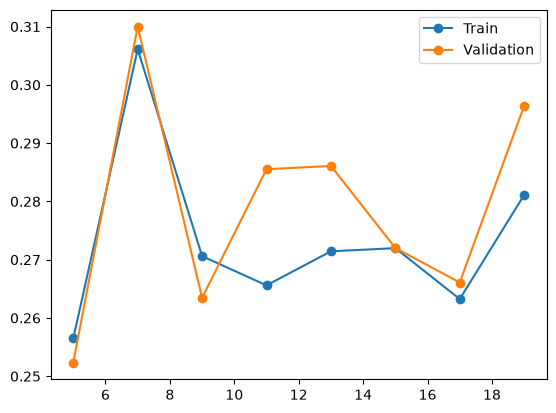

In [15]:
# Errores de train y validaton MSE 
plt.plot(values, train_mses, '-o', label='Train')
plt.plot(values, val_mses, '-o', label='Validation')
plt.legend()
plt.show()

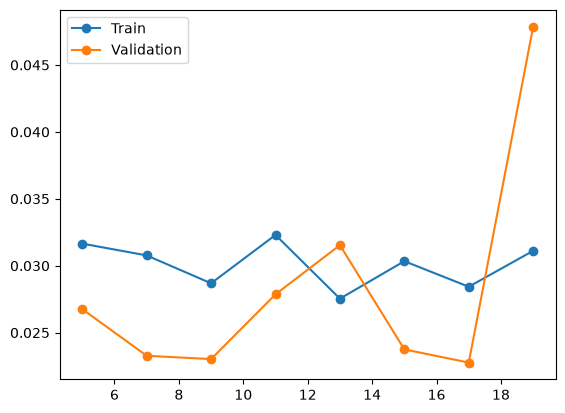

In [16]:
# Errores de train y validaton MAPE 
plt.plot(values, train_mapes, '-o', label='Train')
plt.plot(values, val_mapes, '-o', label='Validation')
plt.legend()
plt.show()

Hallazgos: cómo se comporta el modelo al aumentar neuronas

In [17]:
from sklearn.inspection import permutation_importance

Feature: 0, Score: 0.00000
Feature: 1, Score: 0.12705
Feature: 2, Score: 0.00000
Feature: 3, Score: 0.00000
Feature: 4, Score: 0.00000
Feature: 5, Score: 0.69128
Feature: 6, Score: 0.61322
Feature: 7, Score: 0.51577
Feature: 8, Score: 0.00000
Feature: 9, Score: 0.00000


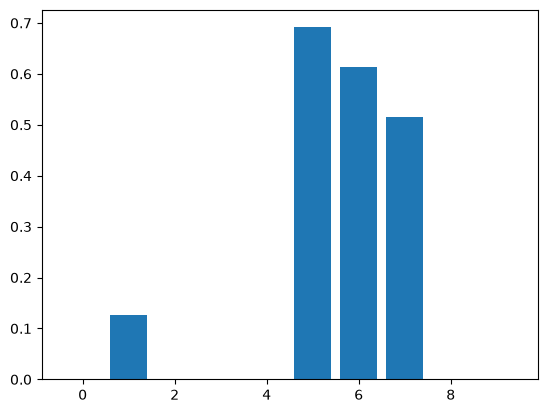

In [18]:
# Una vez inicializado y entrenada la MLP, veamos qué factores considera más importantes:

modelo_MLP = MLPRegressor(hidden_layer_sizes=(11,11), 
                            max_iter=20000, 
                            alpha=0.0001,
                            learning_rate_init=0.001)  

modelo_MLP.fit(X_train, y_train)

importance = permutation_importance(modelo_MLP, X_train, y_train, n_repeats=10)

# visualicemos la importancia de cada métrica, de las cuales sabemos
# cuáles son las más importantes, de acuerdo a como se definieron al inicio:

for i,v in enumerate(importance['importances_mean']):
	print('Feature: %0d, Score: %.5f' % (i,v))
 
plt.bar([x for x in range(len(importance['importances_mean']))], importance['importances_mean'])
plt.show()